In [2]:
# ============================================================
# Setp and data import
# ============================================================
import pandas as pd
import numpy as np
import torch

# Confirm GPU Usage
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Use: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Data import
df = pd.read_csv(r'C:\Users\taori\Documents\GitHub\project-wongoining\tools\phishing_cleaned.csv')

categories = ['Urgency', 'Scarcity', 'Authority', 'Fear', 'Social Proof', 'Reciprocity', 'Liking']

for col in categories:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Keep Phishing + Scam，with label
labelled = df[df['Email Type'].isin(['Phishing Email', 'Scam Email'])].copy()
labelled = labelled.dropna(subset=categories, how='all')
labelled[categories] = labelled[categories].fillna(0).astype(int)

X = labelled['Email Text'].values
y = labelled[categories].values

print(f"\n Data Import Success")
print(f"Total samples: {len(X)}")
print(f"\nLabel distribution:")
for i, cat in enumerate(categories):
    print(f"  {cat}: {y[:, i].sum()} positive ({y[:, i].mean()*100:.1f}%)")

Use: cuda
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU

 Data Import Success
Total samples: 1001

Label distribution:
  Urgency: 692 positive (69.1%)
  Scarcity: 216 positive (21.6%)
  Authority: 430 positive (43.0%)
  Fear: 330 positive (33.0%)
  Social Proof: 198 positive (19.8%)
  Reciprocity: 613 positive (61.2%)
  Liking: 353 positive (35.3%)


In [10]:
# ============================================================
# Baseline Models - one time 80/20 split
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

models = {
    'Naive Bayes':        OneVsRestClassifier(MultinomialNB()),
    'Logistic Regression':OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)),
    'Random Forest':      OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=42)),
    'SVM':                OneVsRestClassifier(LinearSVC(max_iter=1000, random_state=42)),
}

baseline_results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    baseline_results[name] = macro_f1
    print(f"\n{'='*50}")
    print(f"=== {name} | Macro F1: {macro_f1:.4f} ===")
    print('='*50)
    print(classification_report(y_test, y_pred, target_names=categories, zero_division=0))

print("\n Baseline Summary:")
for name, score in sorted(baseline_results.items(), key=lambda x: x[1]):
    print(f"  {name}: {score:.4f}")


=== Naive Bayes | Macro F1: 0.5627 ===
              precision    recall  f1-score   support

     Urgency       0.72      0.99      0.83       137
    Scarcity       1.00      0.04      0.08        46
   Authority       0.90      0.71      0.80        80
        Fear       0.94      0.53      0.67        59
Social Proof       0.75      0.17      0.28        35
 Reciprocity       0.77      1.00      0.87       130
      Liking       0.83      0.27      0.40        75

   micro avg       0.78      0.68      0.73       562
   macro avg       0.84      0.53      0.56       562
weighted avg       0.82      0.68      0.67       562
 samples avg       0.77      0.70      0.70       562


=== Logistic Regression | Macro F1: 0.6432 ===
              precision    recall  f1-score   support

     Urgency       0.75      0.97      0.84       137
    Scarcity       1.00      0.11      0.20        46
   Authority       0.87      0.72      0.79        80
        Fear       0.94      0.54      0.69 

In [11]:
# ============================================================
# Baseline Models - 5-Fold Cross Validation
# ============================================================
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000)),
        ('clf',   OneVsRestClassifier(MultinomialNB()))
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000)),
        ('clf',   OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)))
    ]),
    'Random Forest': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000)),
        ('clf',   OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=42)))
    ]),
    'SVM': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000)),
        ('clf',   OneVsRestClassifier(LinearSVC(max_iter=1000, random_state=42)))
    ]),
}

cv_results = {}

print("5-Fold CV Results (Macro F1):")
print("-" * 40)
for name, model in cv_models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='f1_macro')
    cv_results[name] = scores
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")

5-Fold CV Results (Macro F1):
----------------------------------------
Naive Bayes: 0.5658 ± 0.0147
Logistic Regression: 0.6407 ± 0.0165
Random Forest: 0.6753 ± 0.0121
SVM: 0.7220 ± 0.0154


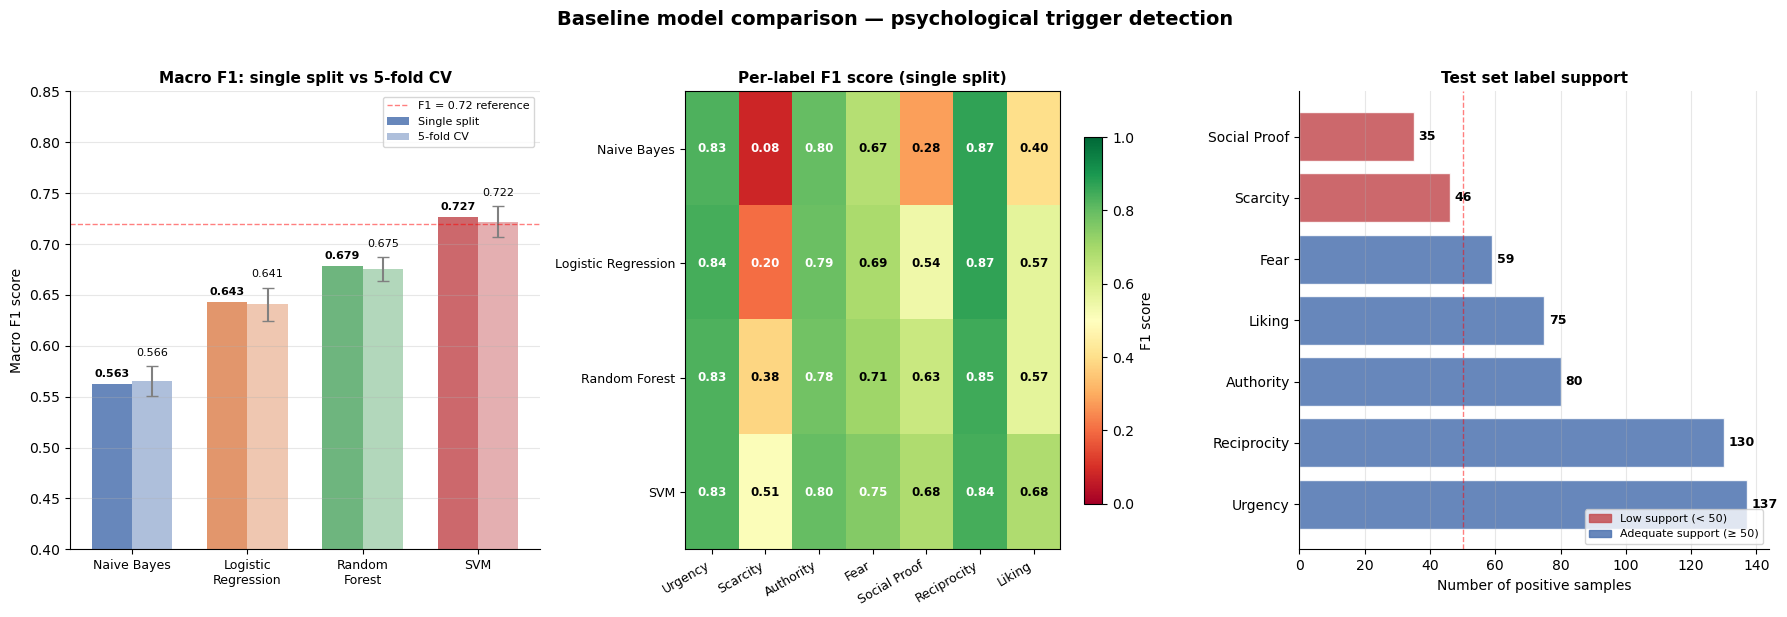

✅ 儲存為 baseline_results_v2.png


In [14]:
# ============================================================
# Baseline Results Visualization
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ---- Data ----
model_names  = ['Naive Bayes', 'Logistic\nRegression', 'Random\nForest', 'SVM']
single_f1    = [0.5627, 0.6432, 0.6786, 0.7265]
cv_mean      = [0.5658, 0.6407, 0.6753, 0.7220]
cv_std       = [0.0147, 0.0165, 0.0121, 0.0154]
colors       = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

per_label = {
    'Naive Bayes':         [0.83, 0.08, 0.80, 0.67, 0.28, 0.87, 0.40],
    'Logistic Regression': [0.84, 0.20, 0.79, 0.69, 0.54, 0.87, 0.57],
    'Random Forest':       [0.83, 0.38, 0.78, 0.71, 0.63, 0.85, 0.57],
    'SVM':                 [0.83, 0.51, 0.80, 0.75, 0.68, 0.84, 0.68],
}

# Support desc.
support_dict = {
    'Urgency': 137, 'Reciprocity': 130, 'Authority': 80,
    'Liking': 75, 'Fear': 59, 'Scarcity': 46, 'Social Proof': 35
}
support_labels = list(support_dict.keys())
support_values = list(support_dict.values())
support_colors = ['#C44E52' if v < 50 else '#4C72B0' for v in support_values]

categories_order = ['Urgency', 'Scarcity', 'Authority', 'Fear',
                    'Social Proof', 'Reciprocity', 'Liking']

x     = np.arange(len(model_names))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Baseline model comparison — psychological trigger detection',
             fontsize=14, fontweight='bold', y=1.02)

# ---- Plot 1: Single Split vs CV ----
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, single_f1, width,
                label='Single split', color=colors, alpha=0.85)
bars2 = ax1.bar(x + width/2, cv_mean, width,
                label='5-fold CV', color=colors, alpha=0.45,
                yerr=cv_std, capsize=4,
                error_kw={'elinewidth': 1.5, 'ecolor': 'grey'})

ax1.set_title('Macro F1: single split vs 5-fold CV', fontweight='bold', fontsize=11)
ax1.set_ylabel('Macro F1 score')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, fontsize=9)
ax1.set_ylim(0.4, 0.85)
ax1.axhline(y=0.72, color='red', linestyle='--', linewidth=1,
            alpha=0.5, label='F1 = 0.72 reference')
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom',
             fontsize=8, fontweight='bold')
for bar, std in zip(bars2, cv_std):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.008,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# ---- Plot 2: Per-label F1 Heatmap ----
ax2 = axes[1]
heat_data = np.array(list(per_label.values()))
im = ax2.imshow(heat_data, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

ax2.set_xticks(range(len(categories_order)))
ax2.set_xticklabels(categories_order, rotation=30, ha='right', fontsize=9)
ax2.set_yticks(range(len(per_label)))
ax2.set_yticklabels(list(per_label.keys()), fontsize=9)
ax2.set_title('Per-label F1 score (single split)', fontweight='bold', fontsize=11)
plt.colorbar(im, ax=ax2, shrink=0.8, label='F1 score')

for i in range(len(per_label)):
    for j in range(len(categories_order)):
        val = heat_data[i, j]
        txt_color = 'black' if 0.25 < val < 0.75 else 'white'
        ax2.text(j, i, f'{val:.2f}', ha='center', va='center',
                 fontsize=8.5, color=txt_color, fontweight='bold')

# ---- Plot 3: Label support (high → low) ----
ax3 = axes[2]
bars3 = ax3.barh(support_labels, support_values,
                 color=support_colors, alpha=0.85, edgecolor='white')

ax3.set_title('Test set label support', fontweight='bold', fontsize=11)
ax3.set_xlabel('Number of positive samples')
ax3.axvline(x=50, color='red', linestyle='--', linewidth=1,
            alpha=0.5, label='n = 50 threshold')
ax3.grid(axis='x', alpha=0.3)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

for bar, val in zip(bars3, support_values):
    ax3.text(bar.get_width() + 1.5,
             bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9, fontweight='bold')

low_patch  = mpatches.Patch(color='#C44E52', alpha=0.85, label='Low support (< 50)')
high_patch = mpatches.Patch(color='#4C72B0', alpha=0.85, label='Adequate support (≥ 50)')
ax3.legend(handles=[low_patch, high_patch], fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('baseline_results_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 儲存為 baseline_results_v2.png")

In [13]:
# ============================================================
# Cell 4: DistilBERT - 5 Epochs (GPU)
# ============================================================
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
import numpy as np

# Dataset Class
class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=512
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

# 數據準備
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

train_dataset = EmailDataset(X_train, y_train, tokenizer)
test_dataset  = EmailDataset(X_test,  y_test,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16)

# Model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=7
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.BCEWithLogitsLoss()

# Training
print("🚀 開始 DistilBERT training (5 epochs, GPU)...\n")
for epoch in range(5):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/5 - Loss: {total_loss/len(train_loader):.4f}")

# Evaluation
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.sigmoid(outputs.logits) > 0.5
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].numpy())

macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
print(f"\n✅ DistilBERT 5ep | Macro F1: {macro_f1:.4f}")
print(classification_report(all_labels, all_preds, target_names=categories, zero_division=0))

C:\Users\taori\anaconda3\envs\phishing_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 4252.91it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if yo

🚀 開始 DistilBERT training (5 epochs, GPU)...

Epoch 1/5 - Loss: 0.6060
Epoch 2/5 - Loss: 0.4850
Epoch 3/5 - Loss: 0.4132
Epoch 4/5 - Loss: 0.3629
Epoch 5/5 - Loss: 0.3204

✅ DistilBERT 5ep | Macro F1: 0.7083
              precision    recall  f1-score   support

     Urgency       0.83      0.81      0.82       137
    Scarcity       0.80      0.26      0.39        46
   Authority       0.86      0.76      0.81        80
        Fear       0.82      0.61      0.70        59
Social Proof       0.65      0.57      0.61        35
 Reciprocity       0.79      0.91      0.85       130
      Liking       0.79      0.79      0.79        75

   micro avg       0.80      0.74      0.77       562
   macro avg       0.79      0.67      0.71       562
weighted avg       0.80      0.74      0.76       562
 samples avg       0.80      0.76      0.75       562



In [15]:
# ============================================================
# Cell 5: DistilBERT - 10 epochs (GPU)
# ============================================================
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
import numpy as np

class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True, max_length=512
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

train_dataset = EmailDataset(X_train, y_train, tokenizer)
test_dataset  = EmailDataset(X_test,  y_test,  tokenizer)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=16)

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=7
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
criterion = nn.BCEWithLogitsLoss()

# Learning rate 線性 decay
total_steps = len(train_loader) * 10
scheduler = LinearLR(optimizer, start_factor=1.0, end_factor=0.1,
                     total_iters=total_steps)

print("🚀 開始 DistilBERT training (10 epochs, GPU)...\n")
for epoch in range(10):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
        loss           = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1:02d}/10 - Loss: {total_loss/len(train_loader):.4f}")

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.sigmoid(outputs.logits) > 0.5
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].numpy())

macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
print(f"\n✅ DistilBERT 10ep | Macro F1: {macro_f1:.4f}")
print(classification_report(all_labels, all_preds,
      target_names=categories, zero_division=0))

Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 4735.69it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🚀 開始 DistilBERT training (10 epochs, GPU)...

Epoch 01/10 - Loss: 0.5959
Epoch 02/10 - Loss: 0.4836
Epoch 03/10 - Loss: 0.4272
Epoch 04/10 - Loss: 0.3848
Epoch 05/10 - Loss: 0.3560
Epoch 06/10 - Loss: 0.3317
Epoch 07/10 - Loss: 0.3110
Epoch 08/10 - Loss: 0.2948
Epoch 09/10 - Loss: 0.2802
Epoch 10/10 - Loss: 0.2697

✅ DistilBERT 10ep | Macro F1: 0.6830
              precision    recall  f1-score   support

     Urgency       0.82      0.85      0.84       137
    Scarcity       0.91      0.22      0.35        46
   Authority       0.82      0.79      0.80        80
        Fear       0.77      0.69      0.73        59
Social Proof       0.65      0.43      0.52        35
 Reciprocity       0.79      0.88      0.83       130
      Liking       0.78      0.65      0.71        75

   micro avg       0.80      0.73      0.76       562
   macro avg       0.79      0.64      0.68       562
weighted avg       0.80      0.73      0.74       562
 samples avg       0.79      0.75      0.74       

In [16]:
# ============================================================
# Cell 6: DistilBERT - 5-Fold CV (5 epochs, GPU)
# ============================================================
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []
fold_reports = []

print("🚀 DistilBERT 5-Fold CV (5 epochs each)...\n")

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f"--- Fold {fold+1}/5 ---")

    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    tr_dataset = EmailDataset(X_tr, y_tr, tokenizer)
    te_dataset = EmailDataset(X_te, y_te, tokenizer)
    tr_loader  = DataLoader(tr_dataset, batch_size=16, shuffle=True)
    te_loader  = DataLoader(te_dataset, batch_size=16)

    fold_model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=7
    )
    fold_model.to(device)

    fold_optimizer = AdamW(fold_model.parameters(), lr=2e-5, weight_decay=0.01)
    fold_criterion = nn.BCEWithLogitsLoss()

    for epoch in range(5):
        fold_model.train()
        total_loss = 0
        for batch in tr_loader:
            fold_optimizer.zero_grad()
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs        = fold_model(input_ids=input_ids, attention_mask=attention_mask)
            loss           = fold_criterion(outputs.logits, labels)
            loss.backward()
            fold_optimizer.step()
            total_loss += loss.item()
        print(f"  Epoch {epoch+1}/5 - Loss: {total_loss/len(tr_loader):.4f}")

    fold_model.eval()
    all_preds, all_labels_fold = [], []
    with torch.no_grad():
        for batch in te_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = fold_model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.sigmoid(outputs.logits) > 0.5
            all_preds.extend(preds.cpu().numpy())
            all_labels_fold.extend(batch['labels'].numpy())

    score = f1_score(all_labels_fold, all_preds, average='macro', zero_division=0)
    fold_scores.append(score)
    print(f"  ✅ Fold {fold+1} Macro F1: {score:.4f}\n")

    # 釋放 GPU 記憶體
    del fold_model
    torch.cuda.empty_cache()

print(f"{'='*40}")
print(f"DistilBERT 5-fold CV: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
print(f"Individual folds: {[round(s,4) for s in fold_scores]}")

🚀 DistilBERT 5-Fold CV (5 epochs each)...

--- Fold 1/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 4545.39it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/5 - Loss: 0.6019
  Epoch 2/5 - Loss: 0.4859
  Epoch 3/5 - Loss: 0.4118
  Epoch 4/5 - Loss: 0.3679
  Epoch 5/5 - Loss: 0.3224
  ✅ Fold 1 Macro F1: 0.7130

--- Fold 2/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 4746.08it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/5 - Loss: 0.6069
  Epoch 2/5 - Loss: 0.4870
  Epoch 3/5 - Loss: 0.4236
  Epoch 4/5 - Loss: 0.3713
  Epoch 5/5 - Loss: 0.3264
  ✅ Fold 2 Macro F1: 0.6979

--- Fold 3/5 ---


...

  Epoch 1/5 - Loss: 0.5941
  Epoch 2/5 - Loss: 0.4875
  Epoch 3/5 - Loss: 0.4318
  Epoch 4/5 - Loss: 0.3758
  Epoch 5/5 - Loss: 0.3384
  ✅ Fold 3 Macro F1: 0.6963

--- Fold 4/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 6666.62it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/5 - Loss: 0.5974
  Epoch 2/5 - Loss: 0.4776
  Epoch 3/5 - Loss: 0.4098
  Epoch 4/5 - Loss: 0.3685
  Epoch 5/5 - Loss: 0.3352
  ✅ Fold 4 Macro F1: 0.6962

--- Fold 5/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 5263.34it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/5 - Loss: 0.5997
  Epoch 2/5 - Loss: 0.4883
  Epoch 3/5 - Loss: 0.4176
  Epoch 4/5 - Loss: 0.3792
  Epoch 5/5 - Loss: 0.3421
  ✅ Fold 5 Macro F1: 0.6892

DistilBERT 5-fold CV: 0.6985 ± 0.0078
Individual folds: [0.713, 0.6979, 0.6963, 0.6962, 0.6892]


In [18]:
# ============================================================
# Cell 8: Rule-based keyword approach
# （用嚟展示點解呢個方法唔work）
# ============================================================
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# ---- 定義每個 trigger 嘅關鍵詞 ----
rules = {
    'Urgency':      ['urgent', 'immediately', 'now', 'today', 'deadline',
                     'expire', 'expires', 'limited time', 'act now',
                     'respond immediately', 'within 24', 'hours', 'asap'],
    'Scarcity':     ['limited', 'only', 'few left', 'last chance',
                     'running out', 'exclusive', 'rare', 'once in a lifetime',
                     'while supplies', 'one time'],
    'Authority':    ['official', 'bank', 'government', 'irs', 'fbi', 'ceo',
                     'manager', 'department', 'administration', 'authorized',
                     'verify', 'compliance', 'legal', 'notice'],
    'Fear':         ['suspend', 'suspended', 'terminate', 'blocked', 'fraud',
                     'unauthorized', 'compromised', 'breach', 'locked',
                     'warning', 'danger', 'risk', 'alert', 'penalty'],
    'Social Proof': ['customers', 'users', 'people', 'everyone', 'thousands',
                     'millions', 'popular', 'trusted', 'community',
                     'others have', 'join us', 'members'],
    'Reciprocity':  ['free', 'gift', 'reward', 'bonus', 'prize', 'offer',
                     'claim', 'benefit', 'receive', 'cash', 'money',
                     'refund', 'discount', 'win', 'won'],
    'Liking':       ['friend', 'family', 'love', 'care', 'personal',
                     'special', 'you deserve', 'exclusive for you',
                     'congratulations', 'selected', 'chosen'],
}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def rule_based_predict(texts, rules, categories):
    preds = []
    for text in texts:
        text_lower = str(text).lower()
        row = []
        for cat in categories:
            keywords = rules[cat]
            matched = any(kw in text_lower for kw in keywords)
            row.append(int(matched))
        preds.append(row)
    return np.array(preds)

y_pred_rule = rule_based_predict(X_test, rules, categories)

macro_f1_rule = f1_score(y_test, y_pred_rule, average='macro', zero_division=0)
print(f"✅ Rule-based | Macro F1: {macro_f1_rule:.4f}")
print()
print(classification_report(y_test, y_pred_rule,
      target_names=categories, zero_division=0))

# ---- 分析關鍵詞重疊問題 ----
print("\n=== 關鍵詞重疊分析 ===")
print("（顯示有幾多 email 被多個 trigger 同時 match，解釋點解 rule-based 唔可靠）\n")

all_matches = rule_based_predict(X_test, rules, categories)
match_counts = all_matches.sum(axis=1)

print(f"平均每封 email 被 match 幾多個 trigger: {match_counts.mean():.2f}")
print(f"被 match 0 個: {(match_counts == 0).sum()} 封")
print(f"被 match 1 個: {(match_counts == 1).sum()} 封")
print(f"被 match 2 個: {(match_counts == 2).sum()} 封")
print(f"被 match 3+ 個: {(match_counts >= 3).sum()} 封")
print()

# ---- 分析每個 trigger 嘅 precision/recall 失衡 ----
print("=== Per-label precision vs recall gap ===")
from sklearn.metrics import precision_score, recall_score
precision = precision_score(y_test, y_pred_rule, average=None, zero_division=0)
recall    = recall_score(y_test, y_pred_rule, average=None, zero_division=0)

print(f"{'Trigger':<15} {'Precision':>10} {'Recall':>10} {'Gap':>10}")
print("-" * 48)
for i, cat in enumerate(categories):
    gap = abs(precision[i] - recall[i])
    print(f"{cat:<15} {precision[i]:>10.3f} {recall[i]:>10.3f} {gap:>10.3f}")

✅ Rule-based | Macro F1: 0.5626

              precision    recall  f1-score   support

     Urgency       0.78      0.74      0.76       137
    Scarcity       0.41      0.52      0.46        46
   Authority       0.63      0.61      0.62        80
        Fear       0.47      0.34      0.39        59
Social Proof       0.37      0.74      0.50        35
 Reciprocity       0.77      0.81      0.79       130
      Liking       0.41      0.44      0.42        75

   micro avg       0.60      0.64      0.62       562
   macro avg       0.55      0.60      0.56       562
weighted avg       0.62      0.64      0.62       562
 samples avg       0.59      0.63      0.57       562


=== 關鍵詞重疊分析 ===
（顯示有幾多 email 被多個 trigger 同時 match，解釋點解 rule-based 唔可靠）

平均每封 email 被 match 幾多個 trigger: 2.97
被 match 0 個: 16 封
被 match 1 個: 32 封
被 match 2 個: 42 封
被 match 3+ 個: 111 封

=== Per-label precision vs recall gap ===
Trigger          Precision     Recall        Gap
----------------------------------------

In [19]:
# ============================================================
# Cell 8b: TF-IDF top keywords per trigger
# （展示唔同 trigger 之間詞彙高度重疊，解釋點解 rule-based 唔 work）
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

print("=== Top TF-IDF keywords per trigger ===\n")

all_top_words = {}

for i, cat in enumerate(categories):
    positive_idx = np.where(y[:, i] == 1)[0]
    negative_idx = np.where(y[:, i] == 0)[0]

    pos_texts = X[positive_idx].tolist()
    neg_texts = X[negative_idx].tolist()

    all_texts  = pos_texts + neg_texts
    labels_bin = [1] * len(pos_texts) + [0] * len(neg_texts)

    vec = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
    X_tfidf = vec.fit_transform(all_texts)

    pos_tfidf = X_tfidf[:len(pos_texts)].mean(axis=0).A1
    words     = vec.get_feature_names_out()
    top_idx   = pos_tfidf.argsort()[::-1][:15]
    top       = [(words[j], round(pos_tfidf[j], 4)) for j in top_idx]

    all_top_words[cat] = [w for w, _ in top]

    print(f"--- {cat} (n={len(pos_texts)}) ---")
    for word, score in top:
        print(f"  {word:<30} {score:.4f}")
    print()

# ---- 重疊分析：找出同時出現喺多個 trigger 嘅高頻詞 ----
print("\n=== 跨 trigger 關鍵詞重疊 ===")
print("（出現喺 3 個或以上 trigger 嘅詞，解釋點解 rule-based 難以區分）\n")

from collections import Counter
all_words_flat = [w for words in all_top_words.values() for w in words]
word_counts    = Counter(all_words_flat)
overlap_words  = {w: c for w, c in word_counts.items() if c >= 3}

for word, count in sorted(overlap_words.items(), key=lambda x: -x[1]):
    triggers = [cat for cat, words in all_top_words.items() if word in words]
    print(f"  '{word}' → 出現喺 {count} 個 trigger: {', '.join(triggers)}")

=== Top TF-IDF keywords per trigger ===

--- Urgency (n=692) ---
  monkey                         0.0376
  org                            0.0365
  monkey org                     0.0363
  com                            0.0310
  jose                           0.0295
  email                          0.0279
  jose monkey                    0.0259
  https                          0.0258
  click                          0.0252
  http                           0.0250
  free                           0.0242
  account                        0.0239
  money                          0.0204
  information                    0.0200
  000                            0.0196

--- Scarcity (n=216) ---
  free                           0.0353
  email                          0.0320
  com                            0.0271
  000                            0.0263
  money                          0.0261
  mail                           0.0258
  time                           0.0239
  account                    

In [24]:
# ============================================================
# Cell 7: RoBERTa - 5 epochs (GPU)
# ============================================================
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
import numpy as np

class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True, max_length=512
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tokenizer_rob = RobertaTokenizer.from_pretrained('roberta-base')

train_dataset = EmailDataset(X_train, y_train, tokenizer_rob)
test_dataset  = EmailDataset(X_test,  y_test,  tokenizer_rob)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=16)

model_rob = RobertaForSequenceClassification.from_pretrained(
    'roberta-base', num_labels=7
)
model_rob.to(device)

optimizer = AdamW(model_rob.parameters(), lr=2e-5, weight_decay=0.01)
criterion = nn.BCEWithLogitsLoss()

print("🚀 開始 RoBERTa training (5 epochs, GPU)...\n")
for epoch in range(5):
    model_rob.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs        = model_rob(input_ids=input_ids, attention_mask=attention_mask)
        loss           = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/5 - Loss: {total_loss/len(train_loader):.4f}")

model_rob.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model_rob(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.sigmoid(outputs.logits) > 0.5
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].numpy())

macro_f1_rob = f1_score(all_labels, all_preds, average='macro', zero_division=0)
print(f"\n✅ RoBERTa 5ep | Macro F1: {macro_f1_rob:.4f}")
print(classification_report(all_labels, all_preds,
      target_names=categories, zero_division=0))

Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 5091.49it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstrea

🚀 開始 RoBERTa training (5 epochs, GPU)...

Epoch 1/5 - Loss: 0.5661
Epoch 2/5 - Loss: 0.4284
Epoch 3/5 - Loss: 0.3635
Epoch 4/5 - Loss: 0.3178
Epoch 5/5 - Loss: 0.2719

✅ RoBERTa 5ep | Macro F1: 0.7379
              precision    recall  f1-score   support

     Urgency       0.79      0.89      0.84       137
    Scarcity       0.62      0.50      0.55        46
   Authority       0.85      0.80      0.83        80
        Fear       0.74      0.68      0.71        59
Social Proof       0.66      0.54      0.59        35
 Reciprocity       0.84      0.88      0.86       130
      Liking       0.75      0.83      0.78        75

   micro avg       0.78      0.79      0.79       562
   macro avg       0.75      0.73      0.74       562
weighted avg       0.78      0.79      0.78       562
 samples avg       0.79      0.80      0.76       562



In [20]:
# ============================================================
# Cell 9: RoBERTa - 優化版 (lr=1e-5, warmup, 5 epochs)
# ============================================================
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
import numpy as np

class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True, max_length=512
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tokenizer_rob = RobertaTokenizer.from_pretrained('roberta-base')

train_dataset = EmailDataset(X_train, y_train, tokenizer_rob)
test_dataset  = EmailDataset(X_test,  y_test,  tokenizer_rob)
train_loader  = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=8)

model_rob2 = RobertaForSequenceClassification.from_pretrained(
    'roberta-base', num_labels=7
)
model_rob2.to(device)

# 細 lr + warmup
NUM_EPOCHS   = 5
total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * 0.1)  # 前 10% steps warmup

optimizer = AdamW(model_rob2.parameters(), lr=1e-5, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)
criterion = nn.BCEWithLogitsLoss()

print(f"🚀 RoBERTa 優化版 (lr=1e-5, warmup={warmup_steps} steps, 5 epochs)...\n")

for epoch in range(NUM_EPOCHS):
    model_rob2.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs        = model_rob2(input_ids=input_ids, attention_mask=attention_mask)
        loss           = criterion(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_rob2.parameters(), 1.0)  # gradient clip
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/5 - Loss: {total_loss/len(train_loader):.4f}")

model_rob2.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model_rob2(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.sigmoid(outputs.logits) > 0.5
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].numpy())

macro_f1_rob2 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
print(f"\n✅ RoBERTa 優化版 | Macro F1: {macro_f1_rob2:.4f}")
print(f"   對比原版: {macro_f1_rob2 - 0.7308:+.4f}")
print()
print(classification_report(all_labels, all_preds,
      target_names=categories, zero_division=0))

Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 5035.61it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstrea

🚀 RoBERTa 優化版 (lr=1e-5, warmup=50 steps, 5 epochs)...

Epoch 1/5 - Loss: 0.6287
Epoch 2/5 - Loss: 0.4662
Epoch 3/5 - Loss: 0.4056
Epoch 4/5 - Loss: 0.3734
Epoch 5/5 - Loss: 0.3531

✅ RoBERTa 優化版 | Macro F1: 0.6969
   對比原版: -0.0339

              precision    recall  f1-score   support

     Urgency       0.83      0.86      0.85       137
    Scarcity       0.78      0.15      0.25        46
   Authority       0.84      0.80      0.82        80
        Fear       0.77      0.63      0.69        59
Social Proof       0.71      0.63      0.67        35
 Reciprocity       0.81      0.92      0.86       130
      Liking       0.77      0.71      0.74        75

   micro avg       0.80      0.75      0.78       562
   macro avg       0.79      0.67      0.70       562
weighted avg       0.80      0.75      0.76       562
 samples avg       0.80      0.77      0.75       562



In [21]:
# ============================================================
# Cell 10: RoBERTa - 5-Fold CV (lr=2e-5, 5 epochs, GPU)
# ============================================================
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
import torch
import torch.nn as nn
from torch.optim import AdamW
import numpy as np

class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True, max_length=512
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

tokenizer_rob = RobertaTokenizer.from_pretrained('roberta-base')
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []

print("🚀 RoBERTa 5-Fold CV (lr=2e-5, 5 epochs each)...\n")

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f"--- Fold {fold+1}/5 ---")

    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    tr_dataset = EmailDataset(X_tr, y_tr, tokenizer_rob)
    te_dataset = EmailDataset(X_te, y_te, tokenizer_rob)
    tr_loader  = DataLoader(tr_dataset, batch_size=16, shuffle=True)
    te_loader  = DataLoader(te_dataset, batch_size=16)

    fold_model = RobertaForSequenceClassification.from_pretrained(
        'roberta-base', num_labels=7
    )
    fold_model.to(device)

    optimizer = AdamW(fold_model.parameters(), lr=2e-5, weight_decay=0.01)
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(5):
        fold_model.train()
        total_loss = 0
        for batch in tr_loader:
            optimizer.zero_grad()
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs        = fold_model(input_ids=input_ids, attention_mask=attention_mask)
            loss           = criterion(outputs.logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"  Epoch {epoch+1}/5 - Loss: {total_loss/len(tr_loader):.4f}")

    fold_model.eval()
    all_preds, all_labels_fold = [], []
    with torch.no_grad():
        for batch in te_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = fold_model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.sigmoid(outputs.logits) > 0.5
            all_preds.extend(preds.cpu().numpy())
            all_labels_fold.extend(batch['labels'].numpy())

    score = f1_score(all_labels_fold, all_preds, average='macro', zero_division=0)
    fold_scores.append(score)
    print(f"  ✅ Fold {fold+1} Macro F1: {score:.4f}\n")

    del fold_model
    torch.cuda.empty_cache()

print(f"{'='*40}")
print(f"RoBERTa 5-fold CV: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
print(f"Individual folds: {[round(s,4) for s in fold_scores]}")

🚀 RoBERTa 5-Fold CV (lr=2e-5, 5 epochs each)...

--- Fold 1/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 4055.99it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstrea

  Epoch 1/5 - Loss: 0.5808
  Epoch 2/5 - Loss: 0.4335
  Epoch 3/5 - Loss: 0.3660
  Epoch 4/5 - Loss: 0.3163
  Epoch 5/5 - Loss: 0.2720
  ✅ Fold 1 Macro F1: 0.7212

--- Fold 2/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 4583.25it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstrea

  Epoch 1/5 - Loss: 0.5648
  Epoch 2/5 - Loss: 0.4377
  Epoch 3/5 - Loss: 0.3884
  Epoch 4/5 - Loss: 0.3535
  Epoch 5/5 - Loss: 0.3048
  ✅ Fold 2 Macro F1: 0.7046

--- Fold 3/5 ---


...

  Epoch 1/5 - Loss: 0.5692
  Epoch 2/5 - Loss: 0.4344
  Epoch 3/5 - Loss: 0.3743
  Epoch 4/5 - Loss: 0.3239
  Epoch 5/5 - Loss: 0.2864
  ✅ Fold 3 Macro F1: 0.7224

--- Fold 4/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 4690.50it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstrea

  Epoch 1/5 - Loss: 0.5610
  Epoch 2/5 - Loss: 0.4289
  Epoch 3/5 - Loss: 0.3716
  Epoch 4/5 - Loss: 0.3397
  Epoch 5/5 - Loss: 0.2904
  ✅ Fold 4 Macro F1: 0.7138

--- Fold 5/5 ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 4348.76it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstrea

  Epoch 1/5 - Loss: 0.5726
  Epoch 2/5 - Loss: 0.4526
  Epoch 3/5 - Loss: 0.3983
  Epoch 4/5 - Loss: 0.3456
  Epoch 5/5 - Loss: 0.3070
  ✅ Fold 5 Macro F1: 0.7410

RoBERTa 5-fold CV: 0.7206 ± 0.0120
Individual folds: [0.7212, 0.7046, 0.7224, 0.7138, 0.741]


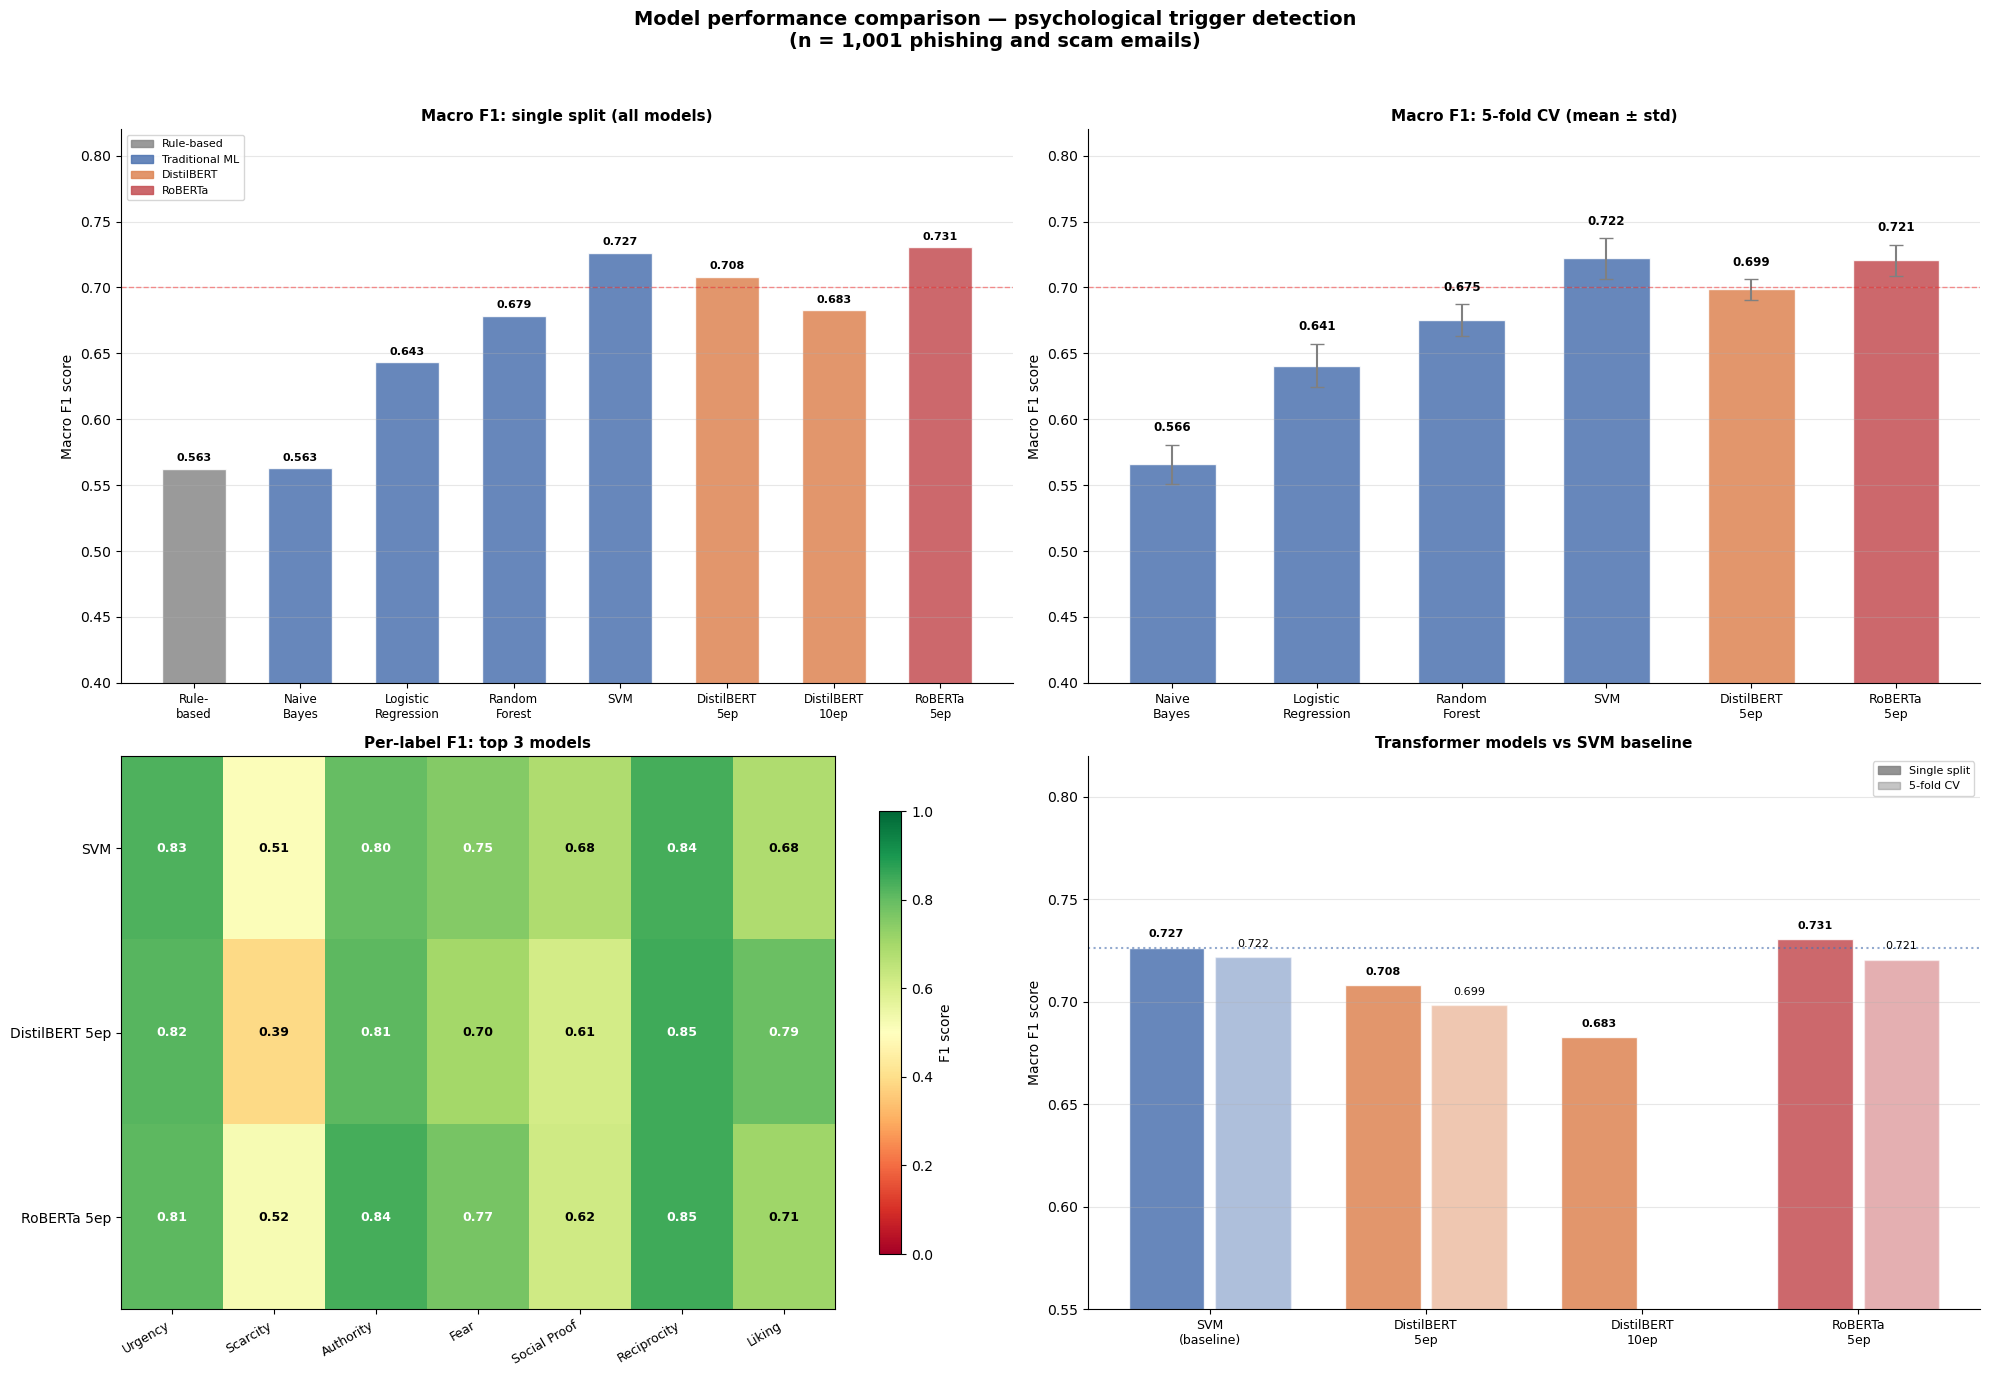

✅ 儲存為 full_model_comparison.png


In [22]:
# ============================================================
# Cell 11: 完整結果視覺化（所有 model）
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ---- 數據 ----
categories_order = ['Urgency','Scarcity','Authority','Fear',
                    'Social Proof','Reciprocity','Liking']

# CV results（有 CV 嘅先放）
cv_models  = ['Naive\nBayes', 'Logistic\nRegression', 'Random\nForest',
              'SVM', 'DistilBERT\n5ep', 'RoBERTa\n5ep']
cv_means   = [0.5658, 0.6407, 0.6753, 0.7220, 0.6985, 0.7206]
cv_stds    = [0.0147, 0.0165, 0.0121, 0.0154, 0.0078, 0.0120]

# Single split（所有 model）
all_models  = ['Rule-\nbased', 'Naive\nBayes', 'Logistic\nRegression',
               'Random\nForest', 'SVM', 'DistilBERT\n5ep',
               'DistilBERT\n10ep', 'RoBERTa\n5ep']
all_single  = [0.5626, 0.5627, 0.6432, 0.6786, 0.7265, 0.7083, 0.6830, 0.7308]
bar_colors  = ['#888888',      # Rule-based (灰)
               '#4C72B0',      # NB
               '#4C72B0',      # LR
               '#4C72B0',      # RF
               '#4C72B0',      # SVM
               '#DD8452',      # DistilBERT 5ep
               '#DD8452',      # DistilBERT 10ep
               '#C44E52']      # RoBERTa

# Per-label F1（best models）
per_label_data = {
    'SVM':           [0.83, 0.51, 0.80, 0.75, 0.68, 0.84, 0.68],
    'DistilBERT 5ep':[0.82, 0.39, 0.81, 0.70, 0.61, 0.85, 0.79],
    'RoBERTa 5ep':   [0.81, 0.52, 0.84, 0.77, 0.62, 0.85, 0.71],
}

fig = plt.figure(figsize=(20, 14))
fig.suptitle('Model performance comparison — psychological trigger detection\n(n = 1,001 phishing and scam emails)',
             fontsize=14, fontweight='bold', y=0.98)

# ---- Plot 1 (top-left): Single split 所有 model ----
ax1 = fig.add_subplot(2, 2, 1)
x1   = np.arange(len(all_models))
bars = ax1.bar(x1, all_single, color=bar_colors, alpha=0.85,
               edgecolor='white', width=0.6)
ax1.set_title('Macro F1: single split (all models)', fontweight='bold', fontsize=11)
ax1.set_ylabel('Macro F1 score')
ax1.set_xticks(x1)
ax1.set_xticklabels(all_models, fontsize=8.5)
ax1.set_ylim(0.4, 0.82)
ax1.axhline(y=0.7, color='red', linestyle='--', linewidth=1, alpha=0.4)
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

for bar, val in zip(bars, all_single):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

rule_patch  = mpatches.Patch(color='#888888', alpha=0.85, label='Rule-based')
ml_patch    = mpatches.Patch(color='#4C72B0', alpha=0.85, label='Traditional ML')
distil_patch= mpatches.Patch(color='#DD8452', alpha=0.85, label='DistilBERT')
rob_patch   = mpatches.Patch(color='#C44E52', alpha=0.85, label='RoBERTa')
ax1.legend(handles=[rule_patch, ml_patch, distil_patch, rob_patch],
           fontsize=8, loc='upper left')

# ---- Plot 2 (top-right): CV 比較（有 CV 嘅 model）----
ax2 = fig.add_subplot(2, 2, 2)
x2      = np.arange(len(cv_models))
cv_cols = ['#4C72B0','#4C72B0','#4C72B0','#4C72B0','#DD8452','#C44E52']
bars2   = ax2.bar(x2, cv_means, color=cv_cols, alpha=0.85,
                  yerr=cv_stds, capsize=5, edgecolor='white', width=0.6,
                  error_kw={'elinewidth': 1.5, 'ecolor': 'grey'})
ax2.set_title('Macro F1: 5-fold CV (mean ± std)', fontweight='bold', fontsize=11)
ax2.set_ylabel('Macro F1 score')
ax2.set_xticks(x2)
ax2.set_xticklabels(cv_models, fontsize=9)
ax2.set_ylim(0.4, 0.82)
ax2.axhline(y=0.7, color='red', linestyle='--', linewidth=1, alpha=0.4)
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for bar, mean, std in zip(bars2, cv_means, cv_stds):
    ax2.text(bar.get_x() + bar.get_width()/2, mean + std + 0.008,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# ---- Plot 3 (bottom-left): Per-label F1 heatmap（top 3 models）----
ax3 = fig.add_subplot(2, 2, 3)
heat_data = np.array(list(per_label_data.values()))
im = ax3.imshow(heat_data, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax3.set_xticks(range(len(categories_order)))
ax3.set_xticklabels(categories_order, rotation=30, ha='right', fontsize=9)
ax3.set_yticks(range(len(per_label_data)))
ax3.set_yticklabels(list(per_label_data.keys()), fontsize=10)
ax3.set_title('Per-label F1: top 3 models', fontweight='bold', fontsize=11)
plt.colorbar(im, ax=ax3, shrink=0.8, label='F1 score')

for i in range(len(per_label_data)):
    for j in range(len(categories_order)):
        val = heat_data[i, j]
        txt_color = 'black' if 0.25 < val < 0.75 else 'white'
        ax3.text(j, i, f'{val:.2f}', ha='center', va='center',
                 fontsize=9, color=txt_color, fontweight='bold')

# ---- Plot 4 (bottom-right): DistilBERT epoch 比較 + RoBERTa ----
ax4 = fig.add_subplot(2, 2, 4)
epoch_models = ['SVM\n(baseline)', 'DistilBERT\n5ep', 'DistilBERT\n10ep', 'RoBERTa\n5ep']
epoch_single = [0.7265, 0.7083, 0.6830, 0.7308]
epoch_cv     = [0.7220, 0.6985, None,   0.7206]
epoch_colors = ['#4C72B0', '#DD8452', '#DD8452', '#C44E52']

x4 = np.arange(len(epoch_models))
bars4a = ax4.bar(x4 - 0.2, epoch_single, 0.35, label='Single split',
                 color=epoch_colors, alpha=0.85, edgecolor='white')

cv_vals_plot = [v if v else 0 for v in epoch_cv]
cv_alpha     = [0.45 if v else 0.0 for v in epoch_cv]
for xi, (val, alpha, col) in enumerate(zip(cv_vals_plot, cv_alpha, epoch_colors)):
    if alpha > 0:
        ax4.bar(xi + 0.2, val, 0.35, color=col, alpha=alpha, edgecolor='white')
        ax4.text(xi + 0.2, val + 0.004, f'{val:.3f}',
                 ha='center', va='bottom', fontsize=8)

ax4.set_title('Transformer models vs SVM baseline', fontweight='bold', fontsize=11)
ax4.set_ylabel('Macro F1 score')
ax4.set_xticks(x4)
ax4.set_xticklabels(epoch_models, fontsize=9)
ax4.set_ylim(0.55, 0.82)
ax4.axhline(y=0.7265, color='#4C72B0', linestyle=':', linewidth=1.5,
            alpha=0.6, label='SVM single split (0.7265)')
ax4.grid(axis='y', alpha=0.3)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

for bar, val in zip(bars4a, epoch_single):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

single_patch = mpatches.Patch(color='grey', alpha=0.85, label='Single split')
cv_patch     = mpatches.Patch(color='grey', alpha=0.45, label='5-fold CV')
ax4.legend(handles=[single_patch, cv_patch], fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('full_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 儲存為 full_model_comparison.png")

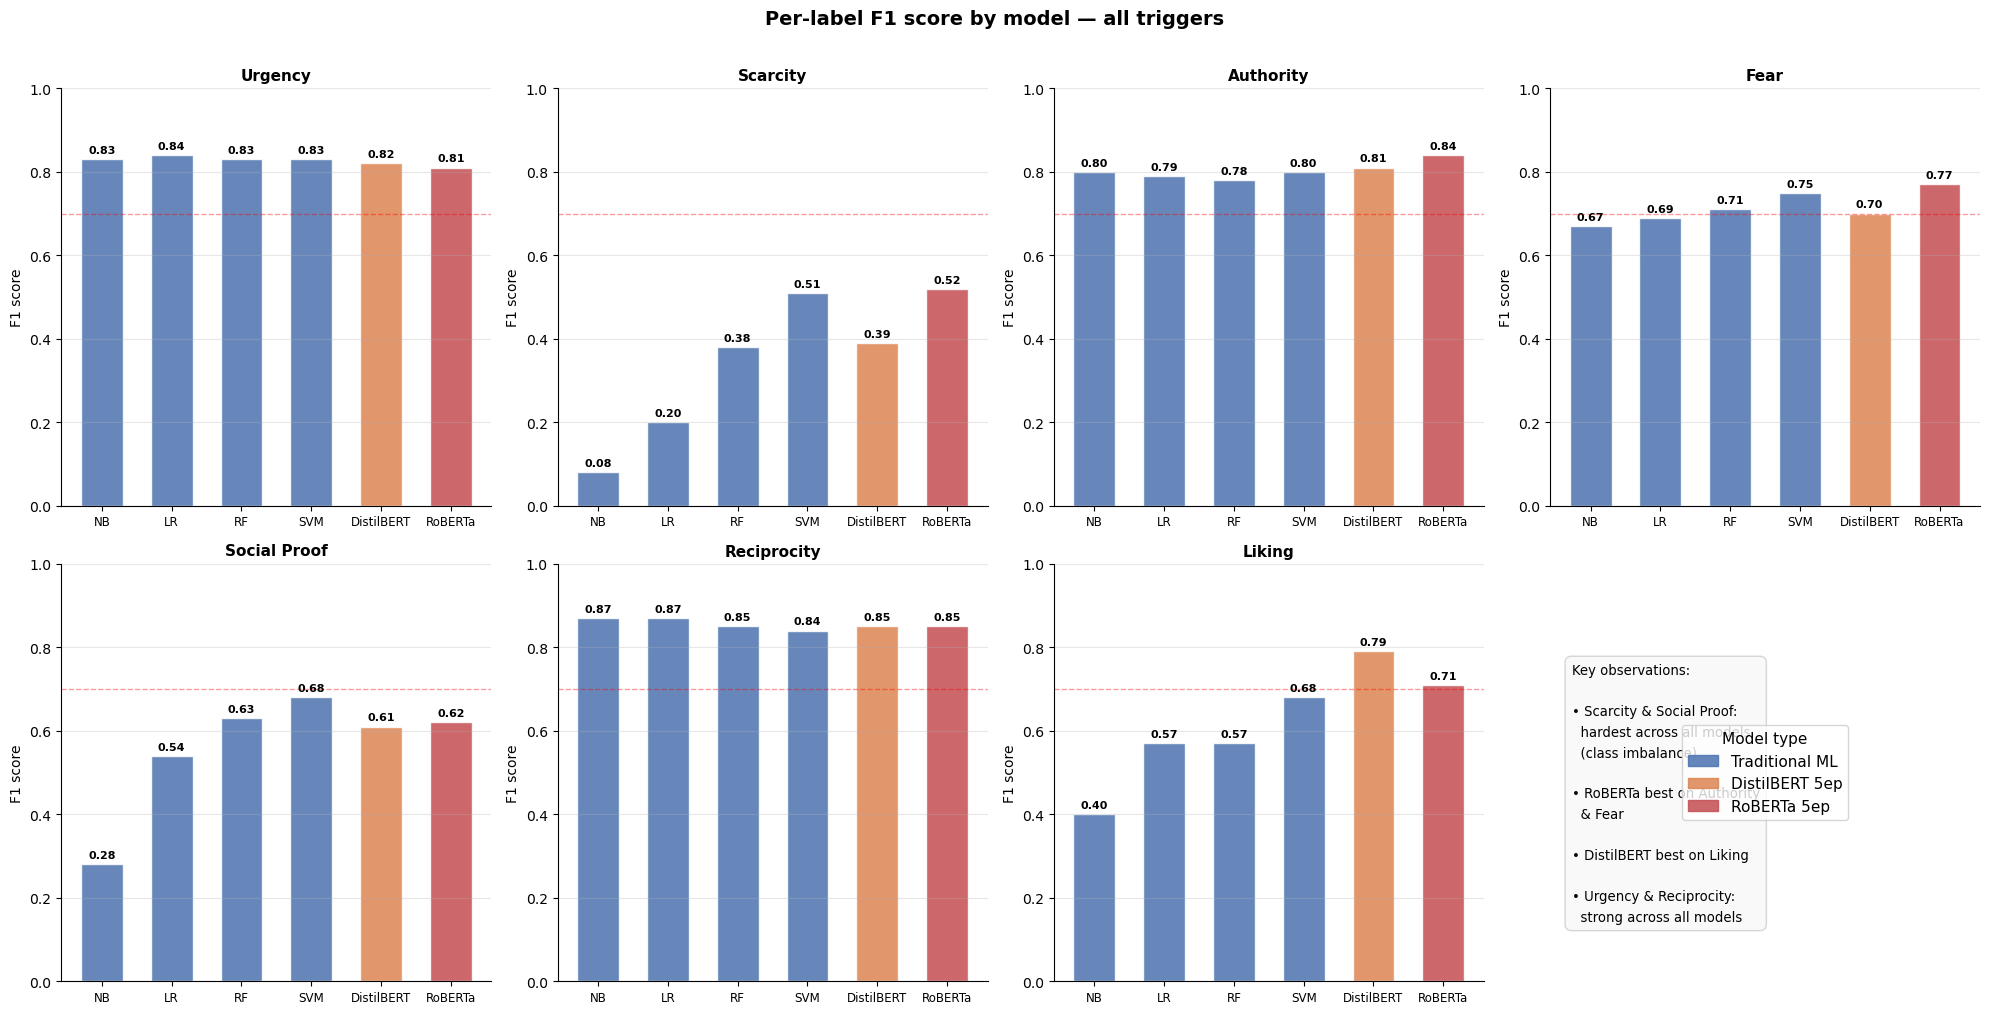

✅ 儲存為 per_label_comparison.png


In [23]:
# ============================================================
# Cell 12: Per-label F1 詳細比較圖
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

categories_order = ['Urgency','Scarcity','Authority','Fear',
                    'Social Proof','Reciprocity','Liking']

# Per-label F1 數據
per_label_all = {
    'Naive Bayes':         [0.83, 0.08, 0.80, 0.67, 0.28, 0.87, 0.40],
    'Logistic Regression': [0.84, 0.20, 0.79, 0.69, 0.54, 0.87, 0.57],
    'Random Forest':       [0.83, 0.38, 0.78, 0.71, 0.63, 0.85, 0.57],
    'SVM':                 [0.83, 0.51, 0.80, 0.75, 0.68, 0.84, 0.68],
    'DistilBERT 5ep':      [0.82, 0.39, 0.81, 0.70, 0.61, 0.85, 0.79],
    'RoBERTa 5ep':         [0.81, 0.52, 0.84, 0.77, 0.62, 0.85, 0.71],
}

model_names = list(per_label_all.keys())
colors = ['#4C72B0','#4C72B0','#4C72B0','#4C72B0','#DD8452','#C44E52']
x = np.arange(len(model_names))
width = 0.13

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Per-label F1 score by model — all triggers',
             fontsize=14, fontweight='bold', y=1.01)

# ---- 每個 trigger 一張圖 ----
for idx, cat in enumerate(categories_order):
    row = idx // 4
    col = idx % 4
    ax  = axes[row][col]

    vals = [per_label_all[m][idx] for m in model_names]
    bars = ax.bar(x, vals, color=colors, alpha=0.85, edgecolor='white', width=0.6)

    ax.set_title(cat, fontweight='bold', fontsize=11)
    ax.set_ylabel('F1 score')
    ax.set_xticks(x)
    ax.set_xticklabels(['NB', 'LR', 'RF', 'SVM', 'DistilBERT', 'RoBERTa'],
                       fontsize=8.5)
    ax.set_ylim(0, 1.0)
    ax.axhline(y=0.7, color='red', linestyle='--', linewidth=1, alpha=0.4)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ---- 最後一格：Summary / Legend ----
ax_last = axes[1][3]
ax_last.axis('off')

import matplotlib.patches as mpatches
ml_patch     = mpatches.Patch(color='#4C72B0', alpha=0.85, label='Traditional ML')
distil_patch = mpatches.Patch(color='#DD8452', alpha=0.85, label='DistilBERT 5ep')
rob_patch    = mpatches.Patch(color='#C44E52', alpha=0.85, label='RoBERTa 5ep')
ax_last.legend(handles=[ml_patch, distil_patch, rob_patch],
               loc='center', fontsize=11, title='Model type',
               title_fontsize=11, frameon=True)

# Summary text
summary = (
    "Key observations:\n\n"
    "• Scarcity & Social Proof:\n"
    "  hardest across all models\n"
    "  (class imbalance)\n\n"
    "• RoBERTa best on Authority\n"
    "  & Fear\n\n"
    "• DistilBERT best on Liking\n\n"
    "• Urgency & Reciprocity:\n"
    "  strong across all models"
)
ax_last.text(0.05, 0.45, summary, transform=ax_last.transAxes,
             fontsize=9.5, va='center', linespacing=1.6,
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f8f8',
                       edgecolor='#cccccc', alpha=0.8))

plt.tight_layout()
plt.savefig('per_label_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 儲存為 per_label_comparison.png")

In [25]:
# ============================================================
# Cell 13: 儲存最佳 model (RoBERTa 5ep)
# ============================================================
import os

save_path = r'C:\Users\taori\Documents\GitHub\project-wongoining\models\roberta_phishing_best'
os.makedirs(save_path, exist_ok=True)

# 注意：呢度用返 Cell 7 跑完嘅 model_rob
# 如果 kernel 重啟過，要重新跑 Cell 7 先
model_rob.save_pretrained(save_path)
tokenizer_rob.save_pretrained(save_path)

print(f"✅ RoBERTa model 已儲存到: {save_path}")
print(f"\n儲存咗嘅檔案：")
for f in os.listdir(save_path):
    size = os.path.getsize(os.path.join(save_path, f)) / (1024*1024)
    print(f"  {f:<40} {size:.1f} MB")

Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.14it/s]

✅ RoBERTa model 已儲存到: C:\Users\taori\Documents\GitHub\project-wongoining\models\roberta_phishing_best

儲存咗嘅檔案：
  config.json                              0.0 MB
  model.safetensors                        475.5 MB
  tokenizer.json                           3.4 MB
  tokenizer_config.json                    0.0 MB


In [4]:
# ============================================================
# Cell 14 修正版: 先載入 saved model 再做 threshold 優化
# ============================================================
import torch
import numpy as np
import pandas as pd
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

# ---- 重新載入數據 ----
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

df = pd.read_csv(r'C:\Users\taori\Documents\GitHub\project-wongoining\tools\phishing_cleaned.csv')
categories = ['Urgency','Scarcity','Authority','Fear','Social Proof','Reciprocity','Liking']
for col in categories:
    df[col] = pd.to_numeric(df[col], errors='coerce')

labelled = df[df['Email Type'].isin(['Phishing Email','Scam Email'])].copy()
labelled = labelled.dropna(subset=categories, how='all')
labelled[categories] = labelled[categories].fillna(0).astype(int)

X = labelled['Email Text'].values
y = labelled[categories].values

_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- 載入 saved model ----
save_path = r'C:\Users\taori\Documents\GitHub\project-wongoining\models\roberta_phishing_best'
tokenizer_rob = RobertaTokenizer.from_pretrained(save_path)
model_rob     = RobertaForSequenceClassification.from_pretrained(save_path)
model_rob.to(device)
print("✅ Model 載入完成")

# ---- Dataset ----
class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True, max_length=512
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

test_dataset = EmailDataset(X_test, y_test, tokenizer_rob)
test_loader  = DataLoader(test_dataset, batch_size=16)

# ---- 拎 raw sigmoid 輸出 ----
model_rob.eval()
all_probs, all_labels_t = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model_rob(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.sigmoid(outputs.logits)
        all_probs.extend(probs.cpu().numpy())
        all_labels_t.extend(batch['labels'].numpy())

all_probs    = np.array(all_probs)
all_labels_t = np.array(all_labels_t)

# ---- 試唔同 threshold ----
print(f"\n{'Threshold':<12} {'Macro F1':<12} {'Micro F1'}")
print("-" * 38)
best_t, best_f1 = 0.5, 0
for t in [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:
    preds  = (all_probs > t).astype(int)
    macro  = f1_score(all_labels_t, preds, average='macro', zero_division=0)
    micro  = f1_score(all_labels_t, preds, average='micro', zero_division=0)
    marker = " ← best" if macro > best_f1 else ""
    print(f"{t:<12} {macro:<12.4f} {micro:.4f}{marker}")
    if macro > best_f1:
        best_f1, best_t = macro, t

print(f"\n✅ 最佳 global threshold: {best_t} (Macro F1: {best_f1:.4f})")

# ---- Per-label 最佳 threshold ----
print(f"\n=== Per-label 最佳 threshold ===")
print(f"{'Trigger':<15} {'Best T':<10} {'F1'}")
print("-" * 35)
for i, cat in enumerate(categories):
    best_cat_t, best_cat_f1 = 0.5, 0
    for t in np.arange(0.2, 0.6, 0.05):
        preds_i = (all_probs[:, i] > t).astype(int)
        f1_i    = f1_score(all_labels_t[:, i], preds_i, zero_division=0)
        if f1_i > best_cat_f1:
            best_cat_f1, best_cat_t = f1_i, t
    print(f"{cat:<15} {best_cat_t:<10.2f} {best_cat_f1:.4f}")

C:\Users\taori\anaconda3\envs\phishing_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


Loading weights: 100%|█████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 5718.42it/s]


✅ Model 載入完成

Threshold    Macro F1     Micro F1
--------------------------------------
0.2          0.7365       0.7650 ← best
0.25         0.7477       0.7798 ← best
0.3          0.7437       0.7814
0.35         0.7441       0.7831
0.4          0.7431       0.7847
0.45         0.7301       0.7815
0.5          0.7379       0.7865

✅ 最佳 global threshold: 0.25 (Macro F1: 0.7477)

=== Per-label 最佳 threshold ===
Trigger         Best T     F1
-----------------------------------
Urgency         0.35       0.8562
Scarcity        0.55       0.5600
Authority       0.30       0.8519
Fear            0.55       0.7290
Social Proof    0.20       0.6596
Reciprocity     0.20       0.8641
Liking          0.25       0.7978
